# Can we predict cell types from factor scores?

### Load packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path
import mofaflex as mfl
import scanpy as sc

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Load model

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/mofa_models")

In [72]:
model_ist = mfl.MOFAFLEX.load(models_path / "model_232_sns")

In [73]:
factors = model_ist.get_factors()

In [74]:
F = factors["group_1"]

In [75]:
cell_names = F.index

### Load lrdata object

In [76]:
data_path = Path("/g/stegle/aalsayah/repos/liana-py/inflow_score_different_annotation")

In [77]:
lrdata = sc.read_h5ad(data_path/ "inflow_score_ist.h5ad")

In [78]:
cell_types = lrdata.obs["typ"]

In [79]:
cell_types = cell_types.sort_index()

In [80]:
F=  F.sort_index()

In [81]:
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [82]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_147_106,0.000775,-0.001111,-0.006394,-0.000952,0.001086,0.231615,-0.844671,-0.805635,-0.000930,-0.001091,-0.448802,-0.000749,0.000765,-0.000261,-0.000586
c_3_147_69,-0.000889,-0.006324,-0.000159,-0.000966,-0.000243,-0.001980,0.001766,0.804599,0.516691,-0.517549,0.000152,0.000101,0.000814,0.001301,0.000500
c_3_148_110,0.000023,0.740926,0.000564,-0.000102,-0.000074,-0.000265,0.096872,0.260581,0.000234,0.000042,-0.270868,-0.108137,-0.001255,-0.000099,-0.051705
c_3_148_120,-1.441311,-1.404780,0.535582,-0.795473,-0.383740,1.787794,1.758947,-0.204969,0.000135,1.549755,-0.002477,0.638947,-1.693461,0.368034,-1.748843
c_3_148_121,-0.493416,-0.627345,-0.764352,-0.000059,-0.011678,-0.000099,0.370378,-0.000393,0.000030,0.807629,-0.512884,0.000066,-1.185288,0.591891,0.001199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_217_975,0.055858,0.106416,-0.000055,1.473853,-0.000276,0.714993,0.000331,-0.000739,0.000020,-0.000007,-0.000819,-0.000206,0.359865,-0.318385,0.343618
c_3_217_977,0.301032,0.444110,0.708472,0.000078,0.000035,0.050255,0.205167,0.000398,0.000252,-0.350297,-0.199314,0.000045,-0.373180,0.149314,-0.000913
c_3_217_979,0.486583,0.000486,0.000105,-0.000090,-0.492452,0.000051,-0.000240,0.000732,0.590265,-0.000272,0.000078,-0.000201,-0.633287,0.001743,0.000079
c_3_217_98,-0.022360,0.323932,-0.320293,-0.396225,0.373650,0.304492,-0.261484,-0.593825,0.000056,-0.000117,0.466939,-0.000126,-0.000527,0.000092,0.000616


In [83]:
filtered_cell_types

c_3_147_106    232_REF
c_3_147_69         NaN
c_3_148_110    232_REF
c_3_148_120    232_REF
c_3_148_121        NaN
                ...   
c_3_217_975    232_CRC
c_3_217_977    232_CRC
c_3_217_979    232_CRC
c_3_217_98     232_CRC
c_3_217_989    232_CRC
Name: typ, Length: 20377, dtype: category
Categories (2, object): ['232_CRC', '232_REF']

In [84]:
print(F.values)  # feature matrix
print(filtered_cell_types.values)  # labels

[[ 7.7531999e-04 -1.1111840e-03 -6.3938494e-03 ...  7.6537288e-04
  -2.6097216e-04 -5.8585830e-04]
 [-8.8910566e-04 -6.3236896e-03 -1.5933267e-04 ...  8.1429363e-04
   1.3012667e-03  4.9969420e-04]
 [ 2.3130306e-05  7.4092579e-01  5.6437915e-04 ... -1.2553524e-03
  -9.9155812e-05 -5.1705498e-02]
 ...
 [ 4.8658314e-01  4.8565882e-04  1.0540196e-04 ... -6.3328683e-01
   1.7431459e-03  7.9158577e-05]
 [-2.2359809e-02  3.2393196e-01 -3.2029340e-01 ... -5.2678725e-04
   9.1740330e-05  6.1624689e-04]
 [ 7.1995747e-01  4.9399278e-01 -3.8658039e-04 ... -4.1096669e-04
   2.8616798e-03 -4.7689843e-01]]
['232_REF', NaN, '232_REF', '232_REF', NaN, ..., '232_CRC', '232_CRC', '232_CRC', '232_CRC', '232_CRC']
Length: 20377
Categories (2, object): ['232_CRC', '232_REF']


In [85]:
X = F.values
y = filtered_cell_types.values  # labels

In [86]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [87]:
print(X.shape, y.shape)

(19786, 15) (19786,)


In [88]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -3.6085424
Max: 3.6136994
Mean: -0.0023846258
Median: -5.0428343e-06
Std dev: 0.39076164


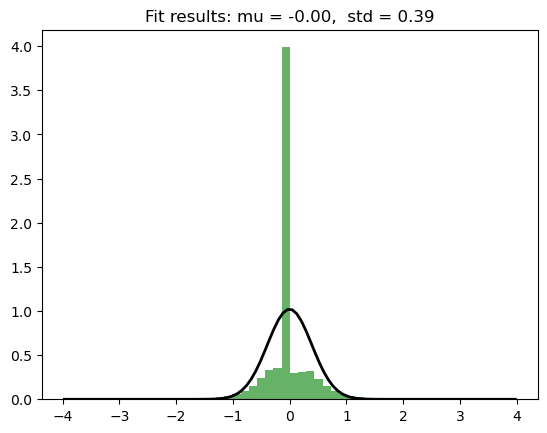

In [89]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


## Regression Model

In [61]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Train multinomial logistic regression - Cell types

In [62]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [63]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [64]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7580862533692723

Classification Report:
               precision    recall  f1-score   support

     232_CRC       0.95      0.75      0.84      5013
     232_REF       0.37      0.78      0.50       923

    accuracy                           0.76      5936
   macro avg       0.66      0.77      0.67      5936
weighted avg       0.86      0.76      0.79      5936



### Train multinomial logistic regression - Condition

In [65]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [66]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [67]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [68]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7580862533692723

Classification Report:
               precision    recall  f1-score   support

     232_CRC       0.95      0.75      0.84      5013
     232_REF       0.37      0.78      0.50       923

    accuracy                           0.76      5936
   macro avg       0.66      0.77      0.67      5936
weighted avg       0.86      0.76      0.79      5936

